In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns   

import statsmodels.api as sm
import statsmodels.stats.api as sms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats


In [2]:
CURRENT = Path.cwd()

if CURRENT.name == "notebooks":
    PROJECT_ROOT = CURRENT.parent
else:
    PROJECT_ROOT = CURRENT

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)
df = pd.read_csv(DATA_DIR / "cs-training.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.shape

(150000, 11)

In [3]:
df_raw = df.copy()
df_model = df.copy()

In [4]:
# Remove duplicates

duplicate_count = df_raw.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df_model = df_model.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_model.shape}")

Number of duplicate rows: 609
Shape after removing duplicates: (149391, 11)


In [5]:
# Handle Age variable

invalid_age_count = (df_model["age"] <= 0).sum()
print(f"Number of rows with invalid age: {invalid_age_count}")

df_model = df_model[df_model["age"] > 0].reset_index(drop=True)
print(f"Shape after removing invalid ages: {df_model.shape}")

Number of rows with invalid age: 1
Shape after removing invalid ages: (149390, 11)


In [6]:
# Median imputation for missing values in Number of Dependents variable

dep_median = df_model["NumberOfDependents"].median()
print(f"Median of NumberOfDependents: {dep_median}")

df_model['NumberOfDependents_missing_flag'] = df_model['NumberOfDependents'].isna().astype(int)
df_model['NumberOfDependents_median'] = df_model['NumberOfDependents'].fillna(dep_median)

print("NumberOfDependents Mean:", df_model['NumberOfDependents'].mean())
print("NumberOfDependents_median Mean:", df_model['NumberOfDependents_median'].mean())

Median of NumberOfDependents: 0.0
NumberOfDependents Mean: 0.7598549071873154
NumberOfDependents_median Mean: 0.7403842291987416


count    149390.000000
mean        354.439110
std        2041.850084
min           0.000000
25%           0.177441
50%           0.368233
75%           0.875294
95%        2455.550000
99%        4985.110000
max      329664.000000
Name: DebtRatio, dtype: float64
Rows affected by capping: 28873
Percentage of rows affected by capping: 19.3272642077783


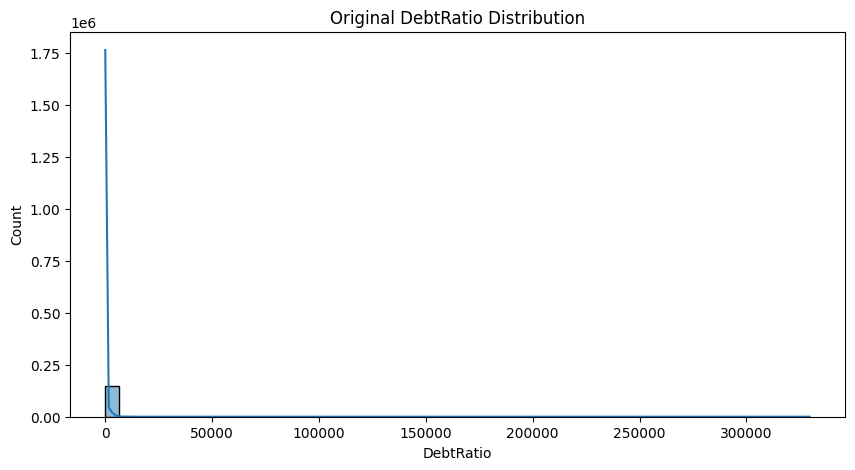

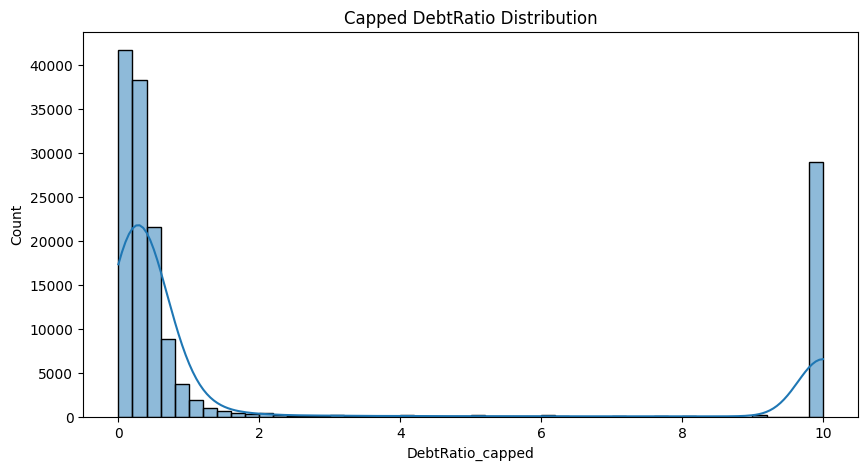

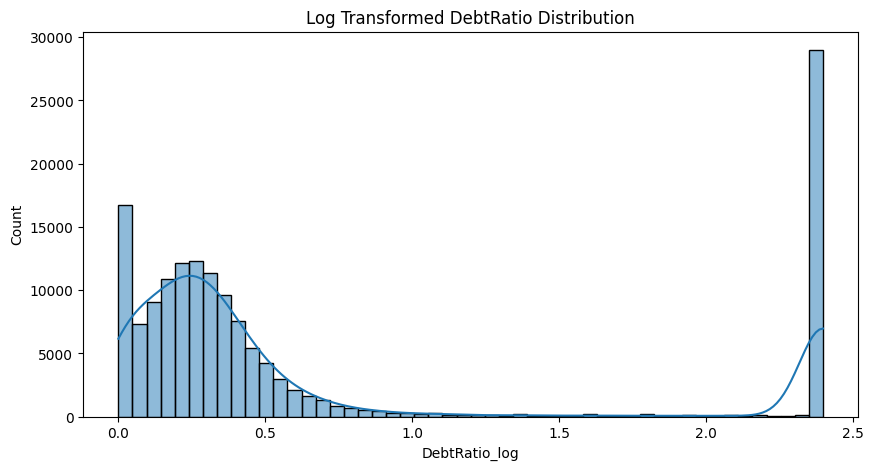

In [7]:
# Treatment of Debt to Income ratio variable to handle outliers and skewness - present largely due to 0 or near 0 income in my opinion.

print(df_model['DebtRatio'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

# Set business cap
# Rationale: p95/p99 are extremely large, so percentile capping is not sufficient.
# A cap of 10 means obligations are 10x income denominator, already extreme. 
# Moreover, I believe there is little signal to be gained from the extreme tail, and it is more likely to be noise or data quality issues.

cap_value = 10
df_model['DebtRatio_high_flag'] = (df_model['DebtRatio'] > cap_value).astype(int)
df_model['DebtRatio_capped'] = np.where(df_model['DebtRatio'] > cap_value, cap_value, df_model['DebtRatio'])

# log transform the capped DebtRatio

df_model['DebtRatio_log'] = np.log1p(df_model['DebtRatio_capped'])

# Check the distribution after transformation

df_model[
    ['DebtRatio', 'DebtRatio_capped', 'DebtRatio_log', 'DebtRatio_high_flag']
].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

# Number of rows affected by capping

print("Rows affected by capping:", df_model['DebtRatio_high_flag'].sum())
print("Percentage of rows affected by capping:", df_model['DebtRatio_high_flag'].mean() * 100)

# Finally, visual comparison of distributions before and after transformation (original vs capped vs log transformed)

plt.figure(figsize=(10, 5))
sns.histplot(df_model['DebtRatio'], bins=50, kde=True)
plt.title('Original DebtRatio Distribution')   
plt.show()   

plt.figure(figsize=(10, 5))
sns.histplot(df_model['DebtRatio_capped'], bins=50, kde=True)
plt.title('Capped DebtRatio Distribution')       
plt.show()   

plt.figure(figsize=(10, 5))
sns.histplot(df_model['DebtRatio_log'], bins=50, kde=True)
plt.title('Log Transformed DebtRatio Distribution')       
plt.show()

DebtRatio displayed severe right-tail distortion in raw form, making direct use inappropriate for linear modeling. A business cap of 10 was applied to neutralize extreme denominator-driven values while preserving high-leverage observations.

The capped variable was then log-transformed, producing a substantially more stable and usable distribution. An additional high-ratio indicator flag was retained to preserve potential distress signal from capped observations.

In [8]:
# Imputation of monthly income using median (robust to outliers)

df_model['MonthlyIncome_missing_flag'] = df_model['MonthlyIncome'].isna().astype(int)
income_median = df_model['MonthlyIncome'].median()
df_model['MonthlyIncome_median'] = df_model['MonthlyIncome'].fillna(income_median)
print("Median Income:", income_median)

Median Income: 5400.0


In [9]:
# Imputation of monthly income using linear regression

## Variable transformations for linear regression imputation model
# Age nonlinear term
df_model["age_sq"] = df_model["age"] ** 2

# Revolving utilization treatment
UTIL_CAP = 2
df_model["RevolvingUtilization_high_flag"] = (
    df_model["RevolvingUtilizationOfUnsecuredLines"] > UTIL_CAP
).astype(int)

df_model["RevolvingUtilization_capped"] = (
    df_model["RevolvingUtilizationOfUnsecuredLines"]
    .clip(lower=0, upper=UTIL_CAP)
)

df_model["RevolvingUtilization_log"] = np.log1p(
    df_model["RevolvingUtilization_capped"]
)

# features to predict missing MonthlyIncome values
income_target = "MonthlyIncome"

income_features = [
    "age",
    "age_sq",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents_median",
    "DebtRatio_log",
    "DebtRatio_high_flag",
    "RevolvingUtilization_log",
    "RevolvingUtilization_high_flag"
]

income_model_df = df_model[income_features + [income_target]].dropna()

# Create X and y for the linear regression model to impute missing MonthlyIncome values
X = income_model_df[income_features]
X = sm.add_constant(X, has_constant="add")
y_log = np.log1p(income_model_df[income_target])

# Split the data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Fit a linear regression model
income_model = sm.OLS(y_train, X_train).fit()
print(income_model.summary())

# Actual income values for validation
y_valid_income = np.expm1(y_valid)

# Run regression 
ols_log = sm.OLS(y_train, X_train).fit()

# Robust SE version for inference if heteroskedasticity exists
ols_log_robust = ols_log.get_robustcov_results(cov_type="HC3")
print(ols_log_robust.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                 3.626e+04
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:50:18   Log-Likelihood:                -92407.
No. Observations:               96135   AIC:                         1.848e+05
Df Residuals:                   96125   BIC:                         1.849e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## A Priori Expected Relationships for MonthlyIncome Imputation Features

- **age**: Expected positive relationship up to mid/late career stages, as earnings generally rise with labor-market experience before flattening near retirement.

- **NumberOfOpenCreditLinesAndLoans**: Expected positive relationship, since borrowers with higher income often qualify for and maintain a broader set of credit products.

- **NumberRealEstateLoansOrLines**: Expected positive relationship, as mortgage/home-equity borrowing is more common among borrowers with sufficient income and accumulated assets.

- **NumberOfDependents_median**: Expected mild positive relationship, since larger households may require greater income capacity, though this can vary materially by life stage.

- **DebtRatio_log**: Expected negative relationship, because higher debt obligations relative to income often indicate lower income capacity or financial strain, after stabilizing extreme values through transformation.

- **DebtRatio_high_flag**: Expected negative relationship, as extremely high debt ratios may proxy severe affordability stress, low reported income, or denominator distortion associated with weaker income profiles.

- **RevolvingUtilizationOfUnsecuredLines**: Expected negative relationship, since persistently high utilization can indicate liquidity pressure or lower disposable income, although the signal may be indirect rather than causal.

               method           RMSE          MAE  R2_on_income_scale
0     Median Baseline   13346.694104  3391.994466           -0.008696
1  Log-OLS + Smearing  164170.845942  8160.866396         -151.617695
                          variable         VIF
0                            const  128.340084
1                              age   42.493264
2                           age_sq   42.718150
3  NumberOfOpenCreditLinesAndLoans    1.330343
4     NumberRealEstateLoansOrLines    1.479950
5        NumberOfDependents_median    1.113168
6                    DebtRatio_log    3.356236
7              DebtRatio_high_flag    3.050741
8         RevolvingUtilization_log    1.168830
9   RevolvingUtilization_high_flag    1.030453


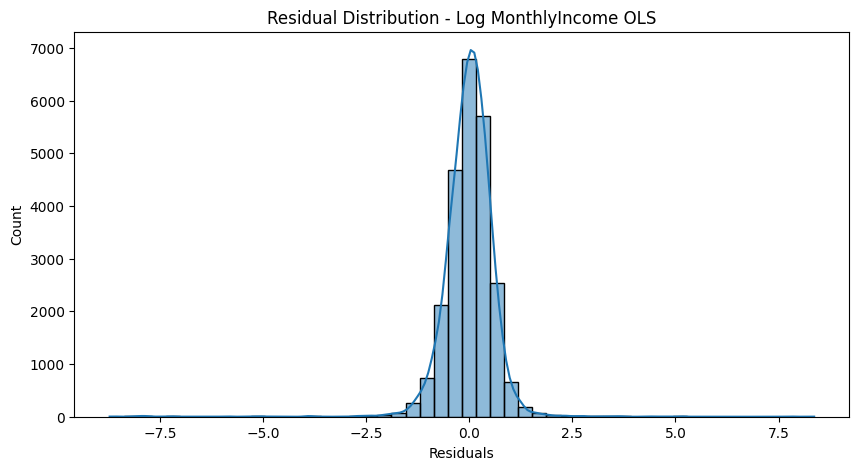

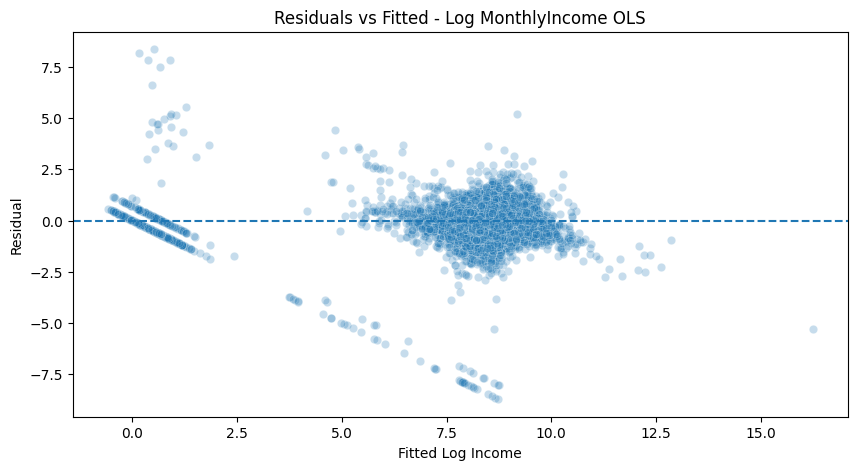

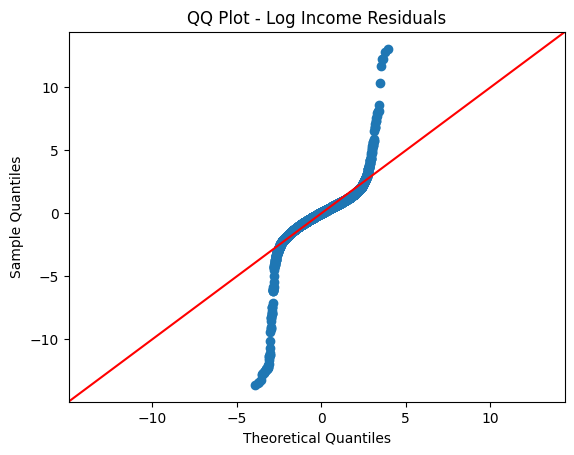

          test     statistic  p_value      skew   kurtosis
0  Jarque-Bera  1.616534e+06      0.0 -2.118454  42.953676
            metric         value
0     LM Statistic  3.907060e+02
1  LM-Test p-value  1.316126e-78
2      F-Statistic  4.411080e+01
3   F-Test p-value  2.865807e-79


In [10]:
# Validation predictions with smearing retransformation to correct for bias in log transformation and diagnostics

valid_pred_log = ols_log.predict(X_valid)
train_residuals = y_train - ols_log.predict(X_train)

# Smearing retransformation
smearing_factor = np.mean(np.exp(train_residuals))
valid_pred_income = (np.exp(valid_pred_log) * smearing_factor) - 1

# Convert predictions with monthly income less than 0 to 0, as negative income is not meaningful in this context
valid_pred_income = np.where(valid_pred_income < 0, 0, valid_pred_income)

# Median baseline
median_pred_income = np.repeat(income_median, len(y_valid_income))

# Metrics
ols_rmse = np.sqrt(mean_squared_error(y_valid_income, valid_pred_income))
ols_mae = mean_absolute_error(y_valid_income, valid_pred_income)
ols_r2 = r2_score(y_valid_income, valid_pred_income)
median_rmse = np.sqrt(mean_squared_error(y_valid_income, median_pred_income))
median_mae = mean_absolute_error(y_valid_income, median_pred_income)
median_r2 = r2_score(y_valid_income, median_pred_income)

comparison = pd.DataFrame({
    "method": ["Median Baseline", "Log-OLS + Smearing"],
    "RMSE": [median_rmse, ols_rmse],
    "MAE": [median_mae, ols_mae],
    "R2_on_income_scale": [median_r2, ols_r2]
})

print(comparison)

# VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_train.columns
vif_df["VIF"] = [variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif_df)

# Residual diagnostics for linear regression imputation model
valid_residuals_log = y_valid - valid_pred_log
valid_fitted_log = valid_pred_log

plt.figure(figsize=(10, 5))
sns.histplot(valid_residuals_log, bins=50, kde=True)
plt.title("Residual Distribution - Log MonthlyIncome OLS")
plt.xlabel("Residuals")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=valid_fitted_log, y=valid_residuals_log, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted - Log MonthlyIncome OLS")
plt.xlabel("Fitted Log Income")
plt.ylabel("Residual")
plt.show()

sm.qqplot(valid_residuals_log, line="45", fit=True)
plt.title("QQ Plot - Log Income Residuals")
plt.show()

# Jarq-Bera test for normality of residuals
jb = sms.jarque_bera(valid_residuals_log)

jb_results = pd.DataFrame({
    "test": ["Jarque-Bera"],
    "statistic": [jb[0]],
    "p_value": [jb[1]],
    "skew": [jb[2]],
    "kurtosis": [jb[3]]
})

print(jb_results)

# Breusch-Pagan test for heteroskedasticity

bp_test = sms.het_breuschpagan(valid_residuals_log, X_valid)

bp_results = pd.DataFrame({
    "metric": [
        "LM Statistic",
        "LM-Test p-value",
        "F-Statistic",
        "F-Test p-value"
    ],
    "value": bp_test
})

print(bp_results)


## MonthlyIncome Missing Value Treatment Review

MonthlyIncome contained missing observations and required formal treatment before model development. Because income is often an economically meaningful predictor in credit risk models, a simple fill method was not adopted immediately. Instead, both baseline and model-based imputation approaches were evaluated.

---

## 1. Baseline Candidate: Median Imputation

The median observed MonthlyIncome was:

- **5,400**

Median imputation was selected as the benchmark because:

- robust to extreme high-income outliers
- not distorted by skewed income distributions
- simple to implement and explain
- stable across samples
- commonly accepted in regulated modeling environments when advanced methods do not provide clear incremental value

A missing-value indicator flag was also retained to preserve potential signal associated with income non-reporting.

---

## 2. Challenger Candidate: OLS Regression Imputation

A challenger model was developed to estimate missing MonthlyIncome using available borrower characteristics.

### Predictor Variables Used

- age  
- NumberOfOpenCreditLinesAndLoans  
- NumberRealEstateLoansOrLines  
- NumberOfDependents_median  
- DebtRatio_log  
- DebtRatio_high_flag  
- RevolvingUtilization_log  
- RevolvingUtilization_high_flag  

### Additional Feature Engineering

Because income relationships are rarely purely linear, several transformations were introduced:

- **age squared** to capture career lifecycle income effects  
- **DebtRatio capped + log transformed** to reduce distortion from extreme values  
- **DebtRatio high flag** to identify anomalous leverage segments  
- **RevolvingUtilization capped + log transformed** to stabilize skewed utilization values  
- **High utilization flag** to identify over-limit / stressed borrowers  

### Target Transformation

MonthlyIncome was strongly right-skewed. Therefore the dependent variable was modeled as:

- **log(1 + MonthlyIncome)**

This materially improved in-sample fit and coefficient stability relative to raw-income OLS.

---

## 3. In-Sample Statistical Results

The transformed OLS model showed:

- strong overall statistical significance
- economically intuitive coefficient directions
- materially higher in-sample R² versus raw-income regression

At first glance, this suggested the challenger model may outperform median imputation.

---

## 4. Diagnostic Review

Residual diagnostics were then performed.

### Findings

- residuals remained heavy-tailed
- strong heteroskedasticity detected (Breusch-Pagan rejection)
- residual structure visible in fitted-vs-residual plots
- retransformation risk present when converting log predictions back to dollar income values

These findings suggested that in-sample goodness-of-fit alone was insufficient for production approval.

---

## 5. Out-of-Sample Validation (Decisive Test)

Both methods were compared on known-income holdout observations.

### Median Baseline

- **RMSE:** 13,346  
- **MAE:** 3,392  

### Log-OLS Challenger

- **RMSE:** 164,171  
- **MAE:** 8,161  

### Interpretation

Despite stronger in-sample fit, the regression challenger materially underperformed the median benchmark out-of-sample.

The primary cause is that small prediction errors on the log scale can translate into very large dollar errors after back-transformation, particularly in upper-income observations.

---

## 6. Final Production Decision

The regression imputation challenger was rejected.

MonthlyIncome missing values will therefore be treated using:

- **Median imputation (5,400)**
- **MonthlyIncome_missing_flag**

---

## 7. Why Median Was Chosen

Median imputation was selected because it demonstrated:

- superior out-of-sample performance versus challenger model
- lower prediction error
- lower implementation risk
- simpler governance and documentation
- robustness to skewed income distribution
- reduced model risk relative to unstable transformed regressions

---

## 8. Final Implementation Logic

For records with observed income:

- retain original MonthlyIncome

For records with missing income:

- replace with 5,400

Additional variable created:

- MonthlyIncome_missing_flag = 1 if originally missing, else 0

---

## 9. Governance Conclusion

Although advanced imputation was explored, benchmark testing demonstrated that added complexity did not improve predictive quality. In line with prudent model risk management principles, the simpler and better-performing treatment was selected for production use.

Original Missing: 29221
Final Missing: 0
       MonthlyIncome  MonthlyIncome_median
count   1.201690e+05          1.493900e+05
mean    6.675104e+03          6.425691e+03
std     1.438964e+04          1.291571e+04
min     0.000000e+00          0.000000e+00
25%     3.400000e+03          3.900000e+03
50%     5.400000e+03          5.400000e+03
75%     8.250000e+03          7.400000e+03
max     3.008750e+06          3.008750e+06
                            observations  bad_rate   avg_income  median_income
MonthlyIncome_missing_flag                                                    
0                                 120169  0.069527  6675.103887         5400.0
1                                  29221  0.056603  5400.000000         5400.0


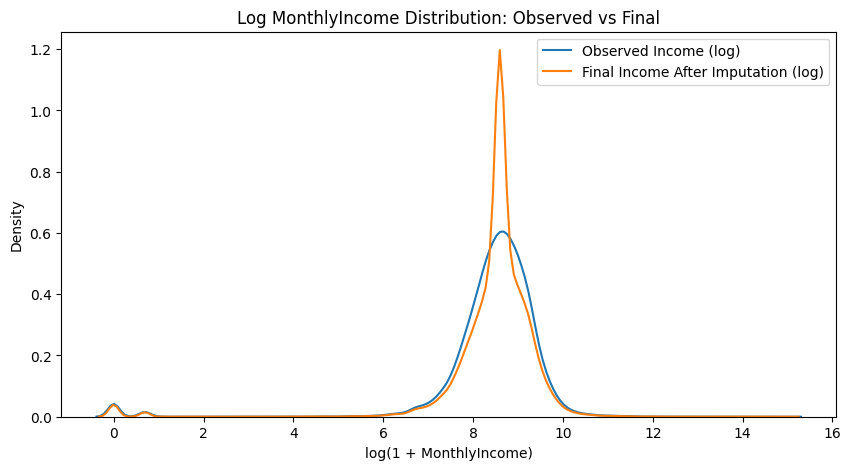

In [11]:
# QA Testing median monthly income imputation on rows with missing MonthlyIncome values

# Missing tests
print("Original Missing:", df_model["MonthlyIncome"].isna().sum())
print("Final Missing:", df_model["MonthlyIncome_median"].isna().sum())

# Statistical summary comparison
summary = df_model[["MonthlyIncome", "MonthlyIncome_median"]].describe()
print(summary)

# Relationship with target variable (SeriousDlqin2yrs) - check if imputation has created any unexpected relationships
qa_target = df_model.groupby("MonthlyIncome_missing_flag").agg(
    observations=("SeriousDlqin2yrs", "count"),
    bad_rate=("SeriousDlqin2yrs", "mean"),
    avg_income=("MonthlyIncome_median", "mean"),
    median_income=("MonthlyIncome_median", "median")
)
print(qa_target)

# Distribution graphs comparison (observed vs final)
observed_income_log = np.log1p(
    df_model.loc[df_model["MonthlyIncome"].notna(), "MonthlyIncome"]
)

final_income_log = np.log1p(df_model["MonthlyIncome_median"])

plt.figure(figsize=(10,5))

sns.kdeplot(
    observed_income_log,
    label="Observed Income (log)"
)

sns.kdeplot(
    final_income_log,
    label="Final Income After Imputation (log)"
)

plt.title("Log MonthlyIncome Distribution: Observed vs Final")
plt.xlabel("log(1 + MonthlyIncome)")
plt.ylabel("Density")
plt.legend()
plt.show()



## MonthlyIncome Final QA Results

MonthlyIncome contained **29,221 missing observations**. Median imputation using the observed portfolio median (**5,400**) was applied and successfully resolved all missing values.

---

## 1. Completeness Review

- Original missing values: **29,221**
- Final missing values after treatment: **0**

This confirms the variable is now fully usable for downstream modeling.

---

## 2. Distribution Review (Log Scale)

Because MonthlyIncome is strongly right-skewed, quality assurance was performed using the log-transformed distribution.

Post-imputation review showed:

- final distribution remained broadly aligned with the observed income distribution
- central portfolio shape was preserved
- expected concentration appeared around the imputed median value
- upper tail observations remained intact

This indicates the imputation method did not materially distort the portfolio income profile.

---

## 3. Summary Statistic Review

- Original observed mean: **6,675**
- Final mean after imputation: **6,426**
- Original observed median: **5,400**
- Final median after imputation: **5,400**
- Maximum value preserved: **3,008,750**

Interpretation:

- mean declined modestly, which is expected when missing values are filled using the median rather than extreme values
- median remained unchanged
- observed high-income records were preserved

---

## 4. Missing Flag Behavior

Bad rate comparison:

- Income reported (flag = 0): **120,169 observations**, bad rate **6.95%**
- Income missing (flag = 1): **29,221 observations**, bad rate **5.66%**

---

## Important Modeling Insight

Records with missing MonthlyIncome exhibited a different default rate than records with reported income. This suggests that **missingness itself may contain predictive information**, rather than representing random data absence.

Accordingly, the variable:

- `MonthlyIncome_missing_flag`

was retained for downstream modeling so the model can capture any incremental signal associated with non-reporting behavior.

---

## 5. Final Production Decision

MonthlyIncome will be carried forward using:

- original reported MonthlyIncome where available
- median imputation (**5,400**) where missing
- MonthlyIncome_missing_flag retained as separate feature

Final production variable:

- `MonthlyIncome_final`

---

## Governance Conclusion

Although more advanced regression-based imputation methods were tested, benchmark validation and QA review showed that median imputation provided the strongest balance of:

- predictive robustness
- distributional stability
- implementation simplicity
- governance transparency
- reduced model risk

Median imputation with a missing-value indicator was therefore approved as the production treatment.

       RevolvingUtilizationOfUnsecuredLines  RevolvingUtilization_log
count                         149390.000000             149390.000000
mean                               6.071121                  0.247160
std                              250.264509                  0.250643
min                                0.000000                  0.000000
25%                                0.030132                  0.029687
50%                                0.154234                  0.143437
75%                                0.556491                  0.442434
max                            50708.000000                  1.098612
Rows above cap: 371
Percent above cap: 0.2483 %


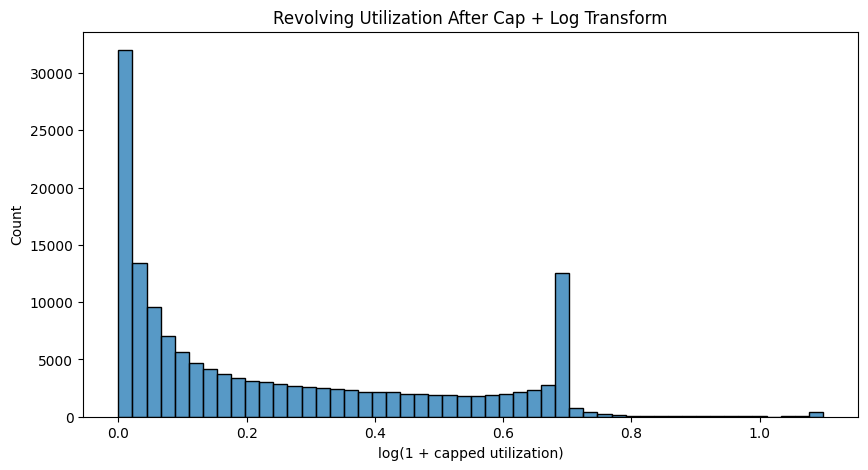

In [12]:
# Treat revolving utilization variable by capping at 2 (200%)

util_capped = 2

raw_col = "RevolvingUtilizationOfUnsecuredLines"

# High flag
df_model["RevolvingUtilization_high_flag"] = (df_model[raw_col] > util_capped).astype(int)

# Cap
util_capped = df_model[raw_col].clip(lower=0, upper=util_capped)

# Log transform
df_model["RevolvingUtilization_log"] = np.log1p(util_capped)

print(df_model[[raw_col, "RevolvingUtilization_log"]].describe())
print("Rows above cap:", df_model["RevolvingUtilization_high_flag"].sum())
print("Percent above cap:", round(df_model["RevolvingUtilization_high_flag"].mean()*100, 4), "%")

# Visualize log revolving utilization distribution after capping and transformation
plt.figure(figsize=(10,5))
sns.histplot(
    df_model["RevolvingUtilization_log"],
    bins=50
)
plt.title("Revolving Utilization After Cap + Log Transform")
plt.xlabel("log(1 + capped utilization)")
plt.show()

## Revolving Utilization Final Treatment

RevolvingUtilizationOfUnsecuredLines exhibited severe right-tail distortion, with a maximum value of 50,708 despite most observations lying below 1.

To stabilize the variable for modeling:

- values were capped at 2
- log transformation was applied using log(1 + x)
- a high-utilization indicator was created for values above the cap

Only 371 observations (0.25% of the portfolio) exceeded the cap, indicating that treatment affected only rare extreme cases while preserving the main borrower population.

The transformed variable showed a materially improved distribution and was approved for downstream modeling use.

In [17]:
# Save the preprocessed dataset for feature engineering
print(df_model.shape)
# CSV
df_model.to_csv(DATA_DIR / "df_model_preprocessed.csv", index=False)

# Parquet
df_model.to_parquet(DATA_DIR / "df_model_preprocessed.parquet", index=False)

print("Files saved successfully.")

(149390, 22)
Files saved successfully.
